# Priorizacion de inspecciones de mantenimiento

**Sistema de deteccion de fallas del sistema de aire comprimido en flota de camiones**

---

## 1. El problema operativo

El sistema de aire comprimido (APS) de un camion pesado alimenta los frenos y los cambios de
marcha. Cuando uno de sus componentes falla en ruta, el vehiculo queda inmovilizado: hay que
enviar asistencia, la carga se retrasa y el taller recibe una reparacion no planificada.

La alternativa es inspeccionar preventivamente. Pero un taller no puede revisar toda la
flota: cada inspeccion ocupa a un mecanico durante un tiempo que no esta disponible para
otra cosa. La pregunta operativa no es *si conviene inspeccionar*, sino **a cuales camiones
inspeccionar cuando no se puede revisar a todos**.

Hoy esa decision se toma por antiguedad del vehiculo, por kilometraje o por criterio del
jefe de taller. Este trabajo evalua si los datos de operacion que la flota ya registra
permiten tomarla mejor.

Este cuaderno continua el analisis exploratorio documentado en `01_eda.ipynb`. Las
decisiones de diseno que se apoyan en hallazgos de esa exploracion se senalan de forma
explicita.

## 2. Los costos, y por que definen todo

La operacion cuantifico ambos errores:

| Error | Que significa en la practica | Costo |
|---|---|---|
| Falso positivo | Se inspecciona un camion sano | **10** |
| Falso negativo | Un camion averiado no se detecta y falla en ruta | **500** |

$$\text{Costo total} = 10 \times FP + 500 \times FN$$

La razon es de **50 a 1**, y esa asimetria determina el diseno del sistema. Conviene aceptar
cincuenta inspecciones innecesarias con tal de evitar una averia en ruta. Cualquier criterio
que trate ambos errores por igual —la exactitud, por ejemplo— llevaria a decisiones
equivocadas.

Esta es la razon por la que el sistema no se evalua con las metricas habituales de
clasificacion, sino directamente en unidades de costo. La pregunta que responde el modelo no
es "cuantos aciertos tuvo" sino **"cuanto dinero ahorra frente a la practica actual"**.

## 3. Los datos

Registros de operacion de camiones pesados Scania en uso cotidiano. La clase positiva
corresponde a camiones con falla en un componente del APS; la negativa, a camiones con
fallas en otros sistemas.

| | |
|---|---|
| Entrenamiento | 60.000 camiones (59.000 sanos, 1.000 con falla APS) |
| Prueba | 16.000 camiones |
| Variables | 170 lecturas de sensores y contadores |
| Proporcion de fallas | 1 de cada 60 |

Las variables estan anonimizadas por confidencialidad industrial: aparecen como `aa_000`,
`ag_002`, etc. Siete de ellas son histogramas —conjuntos de columnas que reparten las
lecturas de un mismo sensor en rangos—, identificables porque comparten prefijo.

Esto limita la interpretacion desde fuera de la empresa, pero no el uso: dentro de la
operacion cada identificador corresponde a una medicion conocida.

---
## 4. Preparacion

In [3]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    average_precision_score, brier_score_loss,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)

SEMILLA = 42
np.random.seed(SEMILLA)

COSTO_FP = 10      # inspeccion innecesaria
COSTO_FN = 500     # averia en ruta no detectada

DIR_DATOS = Path("../data/raw")
DIR_MODELOS = Path("../models")
DIR_MODELOS.mkdir(parents=True, exist_ok=True)

print("Entorno configurado.")

Entorno configurado.


In [4]:
def cargar_aps(ruta):
    """Carga un archivo del conjunto APS.

    El archivo incluye una cabecera de licencia de extension variable, de modo que
    en lugar de fijar un numero de lineas se localiza la fila de encabezados.
    """
    with open(ruta, encoding="utf-8") as f:
        for i, linea in enumerate(f):
            if linea.startswith("class,"):
                return pd.read_csv(ruta, skiprows=i, na_values="na")
    raise ValueError(f"No se encontro la fila de encabezados en {ruta}")


entrenamiento = cargar_aps(DIR_DATOS / "aps_failure_training_set.csv")
prueba = cargar_aps(DIR_DATOS / "aps_failure_test_set.csv")

VARIABLES = [c for c in entrenamiento.columns if c != "class"]

X_ent = entrenamiento[VARIABLES]
y_ent = (entrenamiento["class"] == "pos").astype(int)
X_pru = prueba[VARIABLES]
y_pru = (prueba["class"] == "pos").astype(int)

print(f"Camiones en entrenamiento : {len(X_ent):,}  ({int(y_ent.sum())} con falla APS)")
print(f"Camiones en prueba        : {len(X_pru):,}  ({int(y_pru.sum())} con falla APS)")
print(f"Variables por camion      : {len(VARIABLES)}")
print(f"Proporcion de fallas      : 1 de cada {int((y_ent==0).sum()/(y_ent==1).sum())}")

Camiones en entrenamiento : 60,000  (1000 con falla APS)
Camiones en prueba        : 16,000  (375 con falla APS)
Variables por camion      : 170
Proporcion de fallas      : 1 de cada 59


### 4.1 Dos caracteristicas de los datos que condicionan el diseno

**Sensores que no siempre reportan.** Un 8,3 % de las lecturas esta ausente y ocho columnas
superan el 50 % de ausencias.

La exploracion previa resolvio la pregunta que decide que hacer con ellas. Se contrasto, para
cada lectura, si la tasa de ausencia difiere entre los camiones con falla de APS y el resto;
**ninguna de las diferencias sobrevivio a la correccion por comparaciones multiples**. En este
conjunto, que un sensor no reporte no dice nada sobre el estado del vehiculo: la ausencia es
un problema de telemetria, no un sintoma.

Ese resultado justifica imputar en lugar de preservar la ausencia como senal. Se sustituye
cada valor faltante por la mediana de su lectura, calculada siempre dentro del pliegue de
entrenamiento correspondiente para que ningun estadistico se filtre a la evaluacion. Conviene
ser explicito en un punto que suele confundirse: el algoritmo empleado sabe gestionar valores
ausentes de forma nativa, pero **al imputar antes de entrenar ese mecanismo no se activa**,
porque el modelo ya no ve ningun ausente. La imputacion no complementa al tratamiento nativo,
lo reemplaza. Es una decision deliberada y no un respaldo: se toma porque la exploracion
mostro que no hay senal que preservar, y porque un imputador explicito produce un sistema mas
predecible frente a patrones de ausencia no vistos en operacion.

Las ocho lecturas con cobertura insuficiente se conservan de todos modos. Descartarlas no
aportaria nada —el algoritmo simplemente no las usara si no informan— y mantenerlas evita una
decision arbitraria sobre el umbral de descarte.

**Una falla por cada sesenta camiones sanos.** Sin atender este desequilibrio, un modelo
alcanzaria un 98 % de aciertos declarando que ningun camion tiene falla, y seria inutil. Hay
dos formas de corregirlo —ponderar la clase minoritaria durante el entrenamiento, o dejar que
el umbral de decision absorba el desequilibrio— y la Seccion 11.2 las compara de forma
explicita, porque la eleccion tiene consecuencias sobre como puede comunicarse el resultado.

In [5]:
ausentes = (X_ent.isna().mean() * 100).sort_values(ascending=False)
print(f"Lecturas ausentes en total           : {X_ent.isna().mean().mean()*100:.1f}%")
print(f"Sensores con mas del 50% de ausencias: {(ausentes > 50).sum()}")
print()
print("Sensores con mayor proporcion de ausencias:")
print(ausentes.head(8).round(1).to_string())

# Los histogramas se reconocen porque varias columnas comparten prefijo
prefijos = pd.Series([c.rsplit("_", 1)[0] for c in VARIABLES]).value_counts()
histogramas = prefijos[prefijos > 1]
print(f"\nSensores con lectura por rangos (histogramas): {len(histogramas)}")
print(histogramas.to_string())

Lecturas ausentes en total           : 8.3%
Sensores con mas del 50% de ausencias: 8

Sensores con mayor proporcion de ausencias:
br_000    82.1
bq_000    81.2
bp_000    79.6
bo_000    77.2
ab_000    77.2
cr_000    77.2
bn_000    73.3
bm_000    65.9

Sensores con lectura por rangos (histogramas): 7
ag    10
ay    10
az    10
ba    10
cn    10
cs    10
ee    10


---
## 5. Como se evalua

Antes de entrenar se fijan las referencias contra las que se medira el sistema. Sin ellas,
cualquier cifra de costo carece de significado.

**Referencia 1 — no inspeccionar a nadie.** Es la practica de mantenimiento puramente
correctivo: se atiende cada averia cuando ocurre.

**Referencia 2 — inspeccionar a todos.** Ninguna averia se escapa, pero el taller revisa
dieciseis mil camiones.

El sistema debe situarse muy por debajo de ambas para justificar su implantacion.

In [6]:
def costo_total(y_real, y_estimado):
    """Costo de una politica de inspeccion, en las unidades definidas por la operacion."""
    mc = confusion_matrix(y_real, y_estimado, labels=[0, 1])
    fp, fn = int(mc[0, 1]), int(mc[1, 0])
    return COSTO_FP * fp + COSTO_FN * fn, fp, fn


def curva_costos(y_real, riesgo, umbrales):
    """Costo para muchos umbrales a la vez.

    Equivale a llamar costo_total una vez por umbral, pero se resuelve con dos
    busquedas binarias en lugar de recorrer los datos 800 veces.
    """
    y_real = np.asarray(y_real)
    riesgo = np.asarray(riesgo)
    neg = np.sort(riesgo[y_real == 0])
    pos = np.sort(riesgo[y_real == 1])
    # senalados por encima del umbral que en realidad estaban sanos
    fp = len(neg) - np.searchsorted(neg, umbrales, side="left")
    # con falla que quedan por debajo del umbral
    fn = np.searchsorted(pos, umbrales, side="left")
    return COSTO_FP * fp + COSTO_FN * fn


costo_nada, fp_nada, fn_nada = costo_total(y_pru, np.zeros(len(y_pru), dtype=int))
costo_todo, fp_todo, fn_todo = costo_total(y_pru, np.ones(len(y_pru), dtype=int))

referencias = pd.DataFrame([
    {"Politica": "No inspeccionar a nadie", "Costo": costo_nada,
     "Inspecciones": 0, "Averias en ruta": fn_nada},
    {"Politica": "Inspeccionar a todos", "Costo": costo_todo,
     "Inspecciones": len(y_pru), "Averias en ruta": fn_todo},
])
display(referencias)

print(f"Sobre {len(y_pru):,} camiones, el mantenimiento correctivo cuesta {costo_nada:,}.")
print("Esa es la cifra que el sistema debe reducir.")

,Politica,Costo,Inspecciones,Averias en ruta
0,No inspeccionar a nadie,187500,0,375
1,Inspeccionar a todos,156250,16000,0


Sobre 16,000 camiones, el mantenimiento correctivo cuesta 187,500.
Esa es la cifra que el sistema debe reducir.


---
## 6. El modelo

Se emplea *gradient boosting* sobre arboles de decision: es el metodo de referencia para
datos tabulares de este tamano y permite descomponer cada prediccion en la contribucion de
cada sensor —lo que resulta necesario para que el taller pueda actuar sobre el resultado.

El entrenamiento se realiza en dos etapas. En la primera se separa una quinta parte de los
datos para determinar cuantos arboles construir: el proceso se detiene cuando el desempeno
sobre esa porcion deja de mejorar. En la segunda se ajusta el modelo definitivo sobre los
60.000 camiones con el numero de arboles ya fijado.

Los 16.000 camiones de prueba no intervienen en ninguna de las dos etapas.

In [7]:
X_sub, X_val, y_sub, y_val = train_test_split(
    X_ent, y_ent, test_size=0.20, stratify=y_ent, random_state=SEMILLA
)

PESO_POSITIVO = float((y_sub == 0).sum() / (y_sub == 1).sum())

PARAMETROS_BASE = dict(
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    tree_method="hist",
    random_state=SEMILLA,
    n_jobs=-1,
    eval_metric="aucpr",
)

COTA_ARBOLES = 2000


def construir_preprocesador():
    return SimpleImputer(strategy="median").set_output(transform="pandas")


def construir_tuberia(peso_positivo, n_arboles):
    """Imputacion por mediana seguida del modelo, como una sola unidad."""
    return Pipeline([
        ("imputador", construir_preprocesador()),
        ("modelo", XGBClassifier(**PARAMETROS_BASE,
                                 scale_pos_weight=peso_positivo,
                                 n_estimators=n_arboles)),
    ])


def elegir_n_arboles(peso_positivo):
    """Numero de arboles a partir del cual el desempeno deja de mejorar."""
    prep = construir_preprocesador()
    X_sub_t = prep.fit_transform(X_sub)
    X_val_t = prep.transform(X_val)
    m = XGBClassifier(**PARAMETROS_BASE, scale_pos_weight=peso_positivo,
                      n_estimators=COTA_ARBOLES, early_stopping_rounds=50)
    m.fit(X_sub_t, y_sub, eval_set=[(X_sub_t, y_sub), (X_val_t, y_val)], verbose=False)
    return int(m.best_iteration) + 1


# Etapa 1: cuantos arboles
n_arboles = elegir_n_arboles(PESO_POSITIVO)
print(f"Arboles construidos: {n_arboles} (cota superior: {COTA_ARBOLES})")

Arboles construidos: 854 (cota superior: 2000)


In [8]:
# Etapa 2: modelo definitivo
tuberia = construir_tuberia(PESO_POSITIVO, n_arboles)
tuberia.fit(X_ent, y_ent)

riesgo_pru = tuberia.predict_proba(X_pru)[:, 1]

print(f"Modelo ajustado sobre {len(X_ent):,} camiones.")
print(f"Capacidad de ordenamiento (AUC-ROC) : {roc_auc_score(y_pru, riesgo_pru):.4f}")
print(f"Capacidad de deteccion  (AUC-PR)    : {average_precision_score(y_pru, riesgo_pru):.4f}")

Modelo ajustado sobre 60,000 camiones.
Capacidad de ordenamiento (AUC-ROC) : 0.9958
Capacidad de deteccion  (AUC-PR)    : 0.9336


---
## 7. El umbral de inspeccion

El modelo asigna a cada camion un **puntaje de riesgo**. Convertirlo en una decision requiere
fijar un corte: por encima se inspecciona, por debajo no.

Ese corte es la decision economica del sistema. Un corte bajo genera muchas inspecciones y
pocas averias; uno alto, lo contrario. El valor adecuado es el que minimiza el costo total.

**El corte se determina sin mirar los datos de prueba.** Se estima mediante validacion
cruzada sobre los 60.000 camiones de entrenamiento: se divide en cinco partes, cada una se
puntua con un modelo que no la vio, y sobre esos puntajes se busca el corte de menor costo.
Solo despues se aplica a los 16.000 de prueba, una unica vez.

El motivo de este rodeo es practico: elegir el corte observando los mismos camiones sobre
los que luego se reporta el resultado produce una cifra optimista que no se sostendria en
operacion. La Seccion 11.3 cuantifica esa diferencia.

In [9]:
UMBRALES = np.linspace(0.0005, 0.999, 800)


def umbral_fuera_de_muestra(peso_positivo, n_arboles, etiqueta="", verboso=True):
    """Umbral de menor costo, estimado sobre puntajes de camiones no vistos.

    Cada camion de entrenamiento se puntua con un modelo ajustado sin el. El umbral
    resultante no ha visto en ningun momento los datos de prueba.
    """
    divisor = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
    riesgo_fm = np.zeros(len(X_ent))
    for k, (i_tr, i_te) in enumerate(divisor.split(X_ent, y_ent), 1):
        tub_k = construir_tuberia(peso_positivo, n_arboles)
        tub_k.fit(X_ent.iloc[i_tr], y_ent.iloc[i_tr])
        riesgo_fm[i_te] = tub_k.predict_proba(X_ent.iloc[i_te])[:, 1]
        if verboso:
            print(f"  {etiqueta}parte {k}/5 evaluada")
    costos = curva_costos(y_ent, riesgo_fm, UMBRALES)
    return float(UMBRALES[int(np.argmin(costos))]), riesgo_fm, costos


UMBRAL, riesgo_fuera_muestra, costos_fm = umbral_fuera_de_muestra(PESO_POSITIVO, n_arboles)

# La version vectorizada debe coincidir con el conteo directo
_verif = costo_total(y_ent, (riesgo_fuera_muestra >= UMBRAL).astype(int))[0]
assert _verif == int(curva_costos(y_ent, riesgo_fuera_muestra, np.array([UMBRAL]))[0])

print(f"\nUmbral de inspeccion: {UMBRAL:.4f}")

  parte 1/5 evaluada
  parte 2/5 evaluada
  parte 3/5 evaluada
  parte 4/5 evaluada
  parte 5/5 evaluada

Umbral de inspeccion: 0.0080


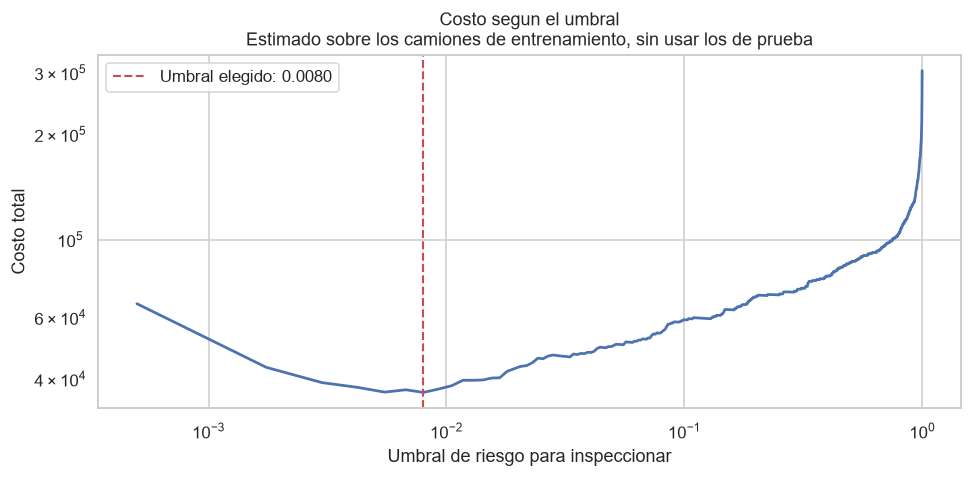

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(UMBRALES, costos_fm, color="#4c72b0", lw=1.8)
ax.axvline(UMBRAL, color="#c44e52", ls="--", lw=1.4, label=f"Umbral elegido: {UMBRAL:.4f}")
ax.set_xlabel("Umbral de riesgo para inspeccionar")
ax.set_ylabel("Costo total")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Costo segun el umbral\nEstimado sobre los camiones de entrenamiento, "
             "sin usar los de prueba")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Resultados

In [11]:
decision = (riesgo_pru >= UMBRAL).astype(int)
COSTO, FP, FN = costo_total(y_pru, decision)

mc = confusion_matrix(y_pru, decision, labels=[0, 1])
print("SOBRE LOS 16.000 CAMIONES DE PRUEBA")
print("=" * 58)
print(f"  Camiones enviados a inspeccion   : {int(decision.sum()):,}")
print(f"  De ellos, con falla real         : {int(mc[1,1]):,}")
print(f"  Inspecciones innecesarias        : {FP:,}")
print(f"  Averias en ruta no detectadas    : {FN}")
print(f"  Averias evitadas                 : {int(mc[1,1]):,} de {int(y_pru.sum())}")
print()
print(f"  COSTO TOTAL                      : {COSTO:,}")
print()
print(pd.DataFrame(mc, index=["Camion sano", "Camion con falla"],
                   columns=["No inspeccionar", "Inspeccionar"]).to_string())

SOBRE LOS 16.000 CAMIONES DE PRUEBA
  Camiones enviados a inspeccion   : 745
  De ellos, con falla real         : 361
  Inspecciones innecesarias        : 384
  Averias en ruta no detectadas    : 14
  Averias evitadas                 : 361 de 375

  COSTO TOTAL                      : 10,840

                  No inspeccionar  Inspeccionar
Camion sano                 15241           384
Camion con falla               14           361


In [12]:
balance = pd.DataFrame([
    {"Politica": "No inspeccionar a nadie", "Costo": costo_nada,
     "Inspecciones": 0, "Averias en ruta": fn_nada},
    {"Politica": "Inspeccionar a todos", "Costo": costo_todo,
     "Inspecciones": len(y_pru), "Averias en ruta": 0},
    {"Politica": "Sistema propuesto", "Costo": COSTO,
     "Inspecciones": int(decision.sum()), "Averias en ruta": FN},
])
balance["Ahorro vs correctivo"] = (costo_nada - balance["Costo"]).map("{:,}".format)
balance["Reduccion"] = ((1 - balance["Costo"] / costo_nada) * 100).round(1).astype(str) + "%"

display(balance)

print(f"El sistema reduce el costo del mantenimiento correctivo en "
      f"{(1 - COSTO/costo_nada)*100:.1f}%.")
print(f"Cada inspeccion realizada evita, en promedio, "
      f"{(costo_nada - COSTO) / max(int(decision.sum()), 1):,.0f} en costos.")

,Politica,Costo,Inspecciones,Averias en ruta,Ahorro vs correctivo,Reduccion
0,No inspeccionar a nadie,187500,0,375,0,0.0%
1,Inspeccionar a todos,156250,16000,0,"31,250",16.7%
2,Sistema propuesto,10840,745,14,"176,660",94.2%


El sistema reduce el costo del mantenimiento correctivo en 94.2%.
Cada inspeccion realizada evita, en promedio, 237 en costos.


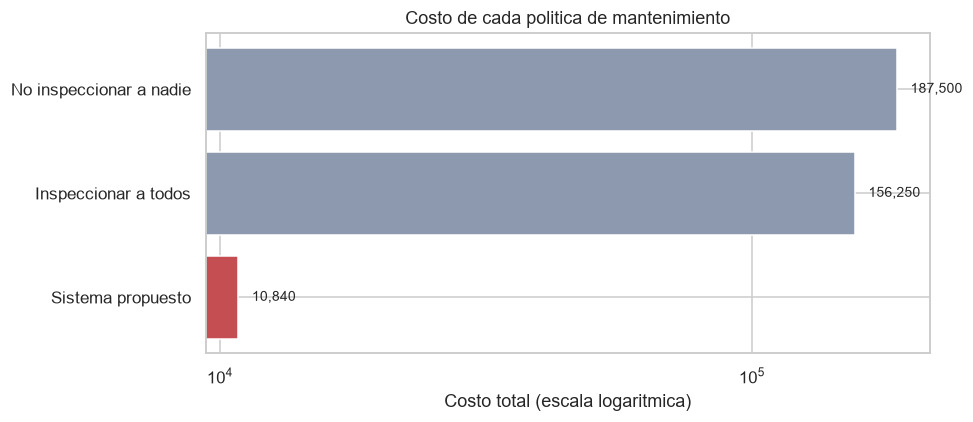

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
colores = ["#8d99ae", "#8d99ae", "#c44e52"]
ax.barh(balance["Politica"], balance["Costo"], color=colores)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Costo total (escala logaritmica)")
ax.set_title("Costo de cada politica de mantenimiento")
for i, v in enumerate(balance["Costo"]):
    ax.text(v * 1.06, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 8.1 Lectura para el taller

El sistema no busca acertar en cada camion, sino minimizar el costo agregado. Eso produce un
comportamiento que conviene explicar antes de implantarlo, porque a primera vista parece un
defecto.

**La mayoria de las inspecciones no encuentran nada.** Es intencionado. Con la razon de
costos de 50 a 1, enviar cincuenta camiones sanos al taller para encontrar uno averiado
sigue siendo mejor negocio que dejar pasar esa averia. Un jefe de taller que juzgue el
sistema por la proporcion de inspecciones "acertadas" concluira que funciona mal; la cifra
que corresponde mirar es el costo total.

**Aun asi, algunas averias se escapan.** Reducirlas a cero exigiria inspeccionar a toda la
flota. El umbral elegido representa el punto donde el costo de las inspecciones adicionales
supera al de las averias que evitarian.

In [14]:
camiones = len(y_pru)
tasa = decision.mean()

print("IMPLICACIONES DE CAPACIDAD")
print("=" * 52)
print(f"Proporcion de la flota enviada a inspeccion: {tasa*100:.1f}%")
print()
for tamano_flota in [500, 2000, 10000]:
    print(f"  Flota de {tamano_flota:>6,} camiones -> "
          f"{tamano_flota*tasa:>7,.0f} inspecciones por ciclo")
print()
print(f"Inspecciones por averia detectada: {decision.sum()/max(int(mc[1,1]),1):.1f}")
print(f"Averias detectadas: {int(mc[1,1])} de {int(y_pru.sum())} "
      f"({mc[1,1]/y_pru.sum()*100:.1f}%)")

IMPLICACIONES DE CAPACIDAD
Proporcion de la flota enviada a inspeccion: 4.7%

  Flota de    500 camiones ->      23 inspecciones por ciclo
  Flota de  2,000 camiones ->      93 inspecciones por ciclo
  Flota de 10,000 camiones ->     466 inspecciones por ciclo

Inspecciones por averia detectada: 2.1
Averias detectadas: 361 de 375 (96.3%)


---
## 9. Que sensores explican la decision

Un aviso de inspeccion sin justificacion obliga al mecanico a revisar el sistema completo.
Para que el sistema ahorre tiempo y no solo lo redistribuya, cada aviso debe indicar que
lecturas lo motivan.

Se emplean valores SHAP, que reparten cada puntaje entre las variables que lo componen. La
suma de las contribuciones reconstruye exactamente el puntaje: no es una aproximacion ni una
regla heuristica.

Las lecturas se agregan por sensor —las columnas que comparten prefijo son rangos de una
misma medicion— porque es a ese nivel al que el taller puede actuar.

In [15]:
modelo_final = tuberia.named_steps["modelo"]
imputador = tuberia.named_steps["imputador"]
X_pru_t = imputador.transform(X_pru)

explicador = shap.TreeExplainer(modelo_final)
valores_shap = explicador.shap_values(X_pru_t)

print(f"Contribuciones calculadas para {valores_shap.shape[0]:,} camiones "
      f"y {valores_shap.shape[1]} lecturas.")

Contribuciones calculadas para 16,000 camiones y 170 lecturas.


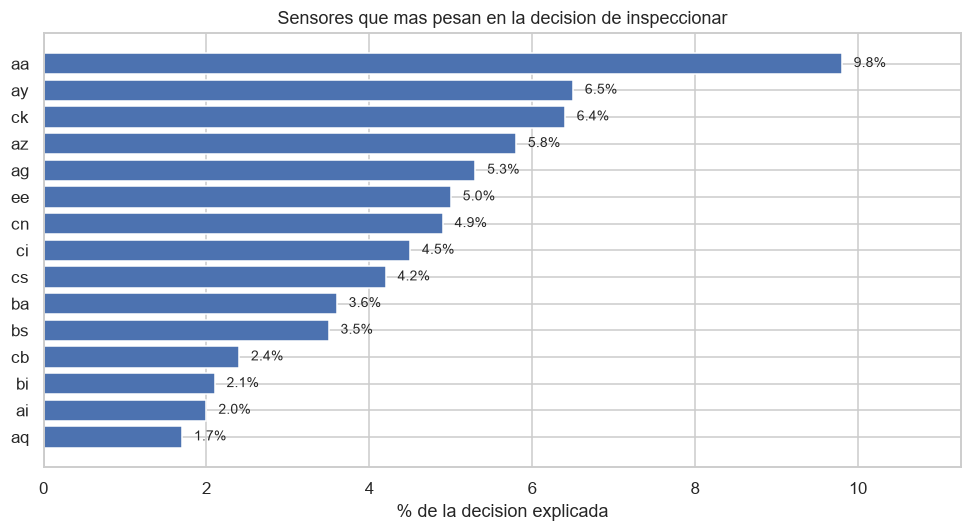

Los cinco sensores principales explican 33.8% de la decision.
Sensores necesarios para explicar la mitad de la decision: 9


In [29]:
importancia = pd.DataFrame({
    "Lectura": X_pru_t.columns,
    "Contribucion": np.abs(valores_shap).mean(axis=0).astype(float),
})
importancia["Sensor"] = importancia["Lectura"].str.rsplit("_", n=1).str[0]

por_sensor = importancia.groupby("Sensor")["Contribucion"].sum().sort_values(ascending=False)
por_sensor_pct = (por_sensor / por_sensor.sum() * 100).round(1)

top = por_sensor_pct.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top.values, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlim(0, top.max() * 1.15)
ax.set_xlabel("% de la decision explicada")
ax.set_title("Sensores que mas pesan en la decision de inspeccionar")
for i, v in enumerate(top.values):
    ax.text(v + top.max() * 0.015, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Los cinco sensores principales explican {por_sensor_pct.head(5).sum():.1f}% "
      f"de la decision.")
print(f"Sensores necesarios para explicar la mitad de la decision: "
      f"{int((por_sensor_pct.cumsum() < 50).sum()) + 1}")

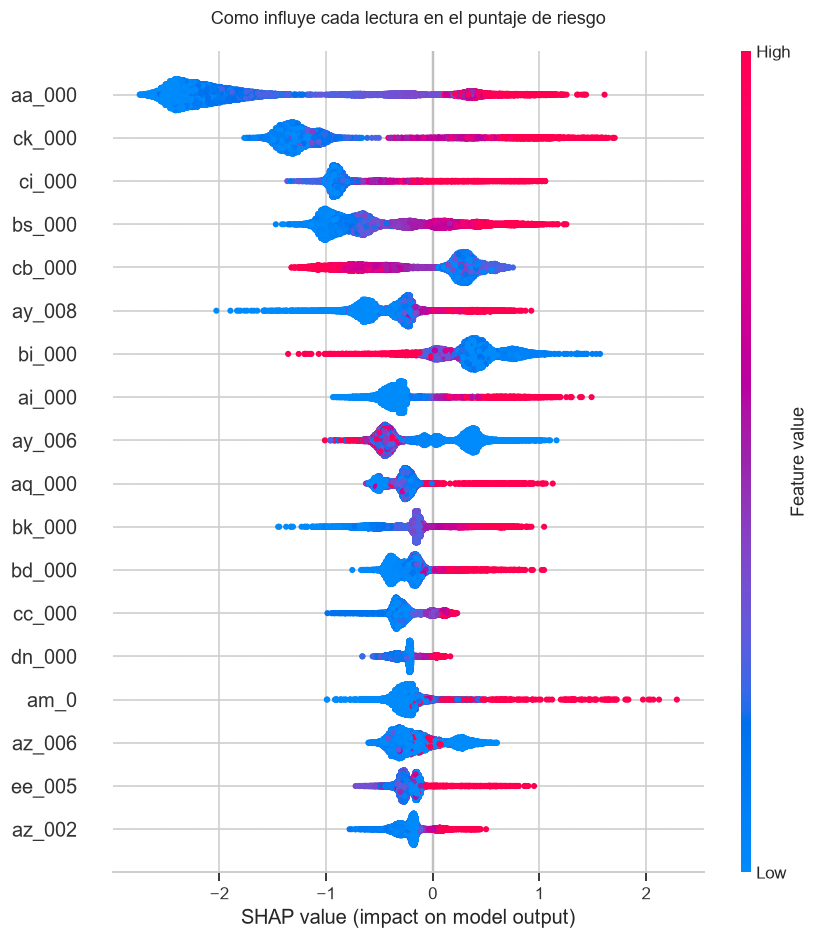

In [17]:
shap.summary_plot(valores_shap, X_pru_t, max_display=18, show=False)
plt.title("Como influye cada lectura en el puntaje de riesgo", pad=18)
plt.tight_layout()
plt.show()

### 9.1 Un aviso, tal como lo recibiria el taller

In [18]:
# Se toma el camion con mayor riesgo entre los senalados
i = int(np.argmax(riesgo_pru))

contrib = pd.DataFrame({
    "Lectura": X_pru_t.columns,
    "Valor": X_pru_t.iloc[i].values,
    "Contribucion": valores_shap[i],
})
contrib["Sensor"] = contrib["Lectura"].str.rsplit("_", n=1).str[0]
top_sensores = (contrib.groupby("Sensor")["Contribucion"].sum()
                .sort_values(ascending=False).head(4))

print("AVISO DE INSPECCION")
print("=" * 52)
print(f"Camion            : T{i:05d}")
print(f"Puntaje de riesgo : {riesgo_pru[i]:.3f}   (umbral: {UMBRAL:.4f})")
print("Recomendacion     : INSPECCIONAR")
print()
print("Sensores que motivan el aviso:")
for sensor, valor in top_sensores.items():
    lecturas = contrib[contrib["Sensor"] == sensor].nlargest(1, "Contribucion")
    print(f"  {sensor:<8} contribucion {valor:+.3f}   "
          f"(lectura destacada: {lecturas['Lectura'].values[0]} = "
          f"{lecturas['Valor'].values[0]:,.0f})")
print()
print(f"Verificacion: falla real registrada = {'SI' if y_pru.iloc[i]==1 else 'NO'}")

AVISO DE INSPECCION
Camion            : T15298
Puntaje de riesgo : 1.000   (umbral: 0.0080)
Recomendacion     : INSPECCIONAR

Sensores que motivan el aviso:
  ag       contribucion +2.800   (lectura destacada: ag_001 = 25,952)
  ay       contribucion +1.002   (lectura destacada: ay_006 = 3,622)
  bs       contribucion +0.806   (lectura destacada: bs_000 = 411,240)
  ck       contribucion +0.804   (lectura destacada: ck_000 = 28,381,722)

Verificacion: falla real registrada = SI


---
## 10. Artefactos del sistema

Lo que sigue produce los archivos que consumira la capa de priorizacion: el modelo ajustado,
el explicador, los metadatos de operacion, la flota puntuada y el rango habitual de cada
lectura.

La flota puntuada guarda unicamente el identificador, el puntaje y la decision. **No incluye
las 170 lecturas originales**, por dos razones: redistribuir el conjunto de datos dentro del
repositorio no corresponde, y la capa de priorizacion no necesita las lecturas crudas sino la
decision y su justificacion.

In [19]:
ruta_modelo = DIR_MODELOS / "modelo_aps.joblib"
joblib.dump(tuberia, ruta_modelo)

ruta_explicador = DIR_MODELOS / "explicador_aps.joblib"
joblib.dump(explicador, ruta_explicador)

metadatos = {
    "sistema": "Priorizacion de inspecciones del sistema de aire comprimido (APS)",
    "decision": "Inspeccionar o no inspeccionar un camion",
    "variables": list(X_ent.columns),
    "n_variables": int(X_ent.shape[1]),
    "n_arboles": int(n_arboles),

    "costos": {
        "inspeccion_innecesaria": COSTO_FP,
        "averia_no_detectada": COSTO_FN,
        "razon": COSTO_FN / COSTO_FP,
    },

    "umbral_inspeccion": {
        "valor": round(UMBRAL, 5),
        "criterio": "minimizacion del costo total sobre puntajes fuera de muestra",
        "advertencia": ("El valor que produce el modelo es un PUNTAJE DE RIESGO, no una "
                        "probabilidad. La ponderacion aplicada para compensar el "
                        "desequilibrio de clases desplaza la escala. Debe comunicarse "
                        "como puntaje y compararse contra el umbral, nunca presentarse "
                        "como porcentaje de probabilidad de falla."),
    },

    "desempeno": {
        "costo_total": int(COSTO),
        "inspecciones": int(decision.sum()),
        "inspecciones_innecesarias": int(FP),
        "averias_no_detectadas": int(FN),
        "averias_detectadas": int(mc[1, 1]),
        "averias_totales": int(y_pru.sum()),
        "tasa_inspeccion": round(float(decision.mean()), 4),
        "auc_roc": round(float(roc_auc_score(y_pru, riesgo_pru)), 4),
    },

    "referencias": {
        "no_inspeccionar_a_nadie": int(costo_nada),
        "inspeccionar_a_todos": int(costo_todo),
        "reduccion_vs_correctivo_pct": round(float((1 - COSTO / costo_nada) * 100), 1),
    },

    "valor_esperado_shap": float(explicador.expected_value),
    "sensores_principales": {str(k): float(v) for k, v in por_sensor_pct.head(20).items()},
}

with open(DIR_MODELOS / "metadatos_aps.json", "w", encoding="utf-8") as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)

# Flota puntuada: solo decision y justificacion, sin las lecturas crudas
principal = importancia.sort_values("Contribucion", ascending=False)["Lectura"].head(3).tolist()
idx_principal = [list(X_pru_t.columns).index(c) for c in principal]

flota = pd.DataFrame({
    "camion_id": [f"T{k:05d}" for k in range(len(X_pru))],
    "riesgo": riesgo_pru,
    "costo_esperado": riesgo_pru * COSTO_FN,
    "senalado": decision,
    "falla_real": y_pru.values,
})
for nombre, j in zip(principal, idx_principal):
    flota[f"shap_{nombre}"] = valores_shap[:, j]

flota.to_csv(DIR_MODELOS / "flota_puntuada.csv", index=False)

# Rango habitual de cada lectura, para detectar camiones fuera de lo conocido
X_ent.describe().T[["min", "25%", "50%", "75%", "max"]].to_csv(
    DIR_MODELOS / "rangos_aps.csv")

for r in ["modelo_aps.joblib", "explicador_aps.joblib", "metadatos_aps.json",
          "flota_puntuada.csv", "rangos_aps.csv"]:
    tam = (DIR_MODELOS / r).stat().st_size / 1e6
    print(f"  guardado: models/{r}  ({tam:.2f} MB)")

  guardado: models/modelo_aps.joblib  (1.94 MB)
  guardado: models/explicador_aps.joblib  (7.65 MB)
  guardado: models/metadatos_aps.json  (0.00 MB)
  guardado: models/flota_puntuada.csv  (1.12 MB)
  guardado: models/rangos_aps.csv  (0.01 MB)


In [20]:
# El modelo guardado debe reproducir exactamente los puntajes
recargado = joblib.load(ruta_modelo)
desvio = float(np.max(np.abs(recargado.predict_proba(X_pru)[:, 1] - riesgo_pru)))
print(f"Desvio entre el modelo en memoria y el guardado: {desvio:.2e}")
print("Artefacto verificado." if desvio < 1e-9 else "ADVERTENCIA: no reproduce.")

print("\nCamiones con mayor costo esperado:")
display(flota.nlargest(8, "costo_esperado")[
    ["camion_id", "riesgo", "costo_esperado", "senalado", "falla_real"]].round(3))

Desvio entre el modelo en memoria y el guardado: 0.00e+00
Artefacto verificado.

Camiones con mayor costo esperado:


,camion_id,riesgo,costo_esperado,senalado,falla_real
15298,T15298,1.0,500.000000,1,1
9396,T09396,1.0,499.998993,1,1
3336,T03336,1.0,499.998993,1,1
13604,T13604,1.0,499.998993,1,1
9795,T09795,1.0,499.998993,1,1
14425,T14425,1.0,499.997986,1,1
1161,T01161,1.0,499.997986,1,1
14088,T14088,1.0,499.997986,1,1


---
## 11. Verificaciones y limitaciones

### 11.1 El modelo memoriza los datos de entrenamiento

El desempeno sobre los camiones empleados para entrenar es perfecto, mientras que sobre los
de prueba es alto pero no perfecto. Es memorizacion: con 170 variables y suficientes arboles,
el modelo puede reproducir de memoria los casos que vio.

Esto no invalida el resultado —la cifra que importa es la de prueba, obtenida sobre camiones
que el modelo nunca vio— pero conviene registrarlo. No se ajustaron los parametros para
reducirlo, porque hacerlo observando el conjunto de prueba habria comprometido la
independencia de la evaluacion.

In [21]:
print("DESEMPENO POR CONJUNTO")
print("=" * 62)
for nombre, X, yy, visto in [("Entrenamiento", X_sub, y_sub, "si"),
                             ("Validacion", X_val, y_val, "si"),
                             ("Prueba", X_pru, y_pru, "NO")]:
    r = tuberia.predict_proba(X)[:, 1]
    ct, fp, fn = costo_total(yy, (r >= UMBRAL).astype(int))
    print(f"{nombre:14s} visto:{visto:>3}  AUC-PR {average_precision_score(yy, r):.4f}  "
          f"averias no detectadas: {fn:>3}")
print()
print("Solo la fila de prueba constituye una estimacion valida del desempeno en operacion.")

DESEMPENO POR CONJUNTO
Entrenamiento  visto: si  AUC-PR 1.0000  averias no detectadas:   0
Validacion     visto: si  AUC-PR 1.0000  averias no detectadas:   0
Prueba         visto: NO  AUC-PR 0.9336  averias no detectadas:  14

Solo la fila de prueba constituye una estimacion valida del desempeno en operacion.


### 11.2 El puntaje no es una probabilidad, y eso es una consecuencia del diseno

La ponderacion aplicada para compensar el desequilibrio de clases desplaza la escala de
salida del modelo. Un valor de 0,80 no significa "80 % de probabilidad de falla".

**Primer intento: corregirlo con calibracion.** Sin exito. El ajuste empeoro la medida de
calibracion y, aplicado con el umbral teorico que se deriva de los costos, incremento el
costo total. El desequilibrio de 60 a 1 deforma la escala de un modo que el metodo empleado
no reproduce.

**Segundo intento, y la pregunta de fondo: hacia falta ponderar.** Conviene notar que el
sistema aplica *dos* correcciones al desequilibrio y no una: pondera la clase minoritaria
durante el entrenamiento **y** ademas optimiza el umbral por costo. Las dos hacen el mismo
trabajo. Si el umbral absorbe el desequilibrio por si solo, la ponderacion resulta
prescindible — y con ella desapareceria la deformacion de la escala que impide interpretar el
puntaje como probabilidad.

Se comprueba entrenando la variante sin ponderacion, con el mismo procedimiento completo:
seleccion propia del numero de arboles, umbral estimado fuera de muestra por validacion
cruzada, y una unica evaluacion final sobre los camiones de prueba. Las dos alternativas se
comparan por costo, que es el criterio del sistema.

Esta seccion es la mas costosa del cuaderno en tiempo de computo, porque repite el
entrenamiento completo. La comparacion lo justifica: determina si la principal limitacion del
sistema es inevitable o autoinfligida.

In [22]:
# Verificacion documentada de la calibracion
from sklearn.calibration import CalibratedClassifierCV

calibrado = CalibratedClassifierCV(
    construir_tuberia(PESO_POSITIVO, n_arboles), method="sigmoid", cv=5)
calibrado.fit(X_ent, y_ent)
riesgo_cal = calibrado.predict_proba(X_pru)[:, 1]

UMBRAL_TEORICO = COSTO_FP / COSTO_FN     # 0.02, derivado solo de los costos
ct_sin = costo_total(y_pru, (riesgo_pru >= UMBRAL_TEORICO).astype(int))[0]
ct_cal = costo_total(y_pru, (riesgo_cal >= UMBRAL_TEORICO).astype(int))[0]

print("Medida de calibracion (Brier, menor es mejor)")
print(f"  sin calibrar : {brier_score_loss(y_pru, riesgo_pru):.5f}")
print(f"  calibrado    : {brier_score_loss(y_pru, riesgo_cal):.5f}")
print()
print(f"Costo con el umbral teorico ({UMBRAL_TEORICO}):")
print(f"  sin calibrar : {ct_sin:,}")
print(f"  calibrado    : {ct_cal:,}")
print()
print(f"Costo del sistema adoptado (umbral empirico): {COSTO:,}")
print("\nLa calibracion no mejora el sistema. Se descarta y se documenta.")

Medida de calibracion (Brier, menor es mejor)
  sin calibrar : 0.00478
  calibrado    : 0.00493

Costo con el umbral teorico (0.02):
  sin calibrar : 11,630
  calibrado    : 21,040

Costo del sistema adoptado (umbral empirico): 10,840

La calibracion no mejora el sistema. Se descarta y se documenta.


In [23]:
# Variante sin ponderacion: el umbral absorbe todo el desequilibrio
n_arboles_sp = elegir_n_arboles(1.0)
print(f"Arboles de la variante sin ponderar: {n_arboles_sp}")

UMBRAL_SP, riesgo_fm_sp, costos_fm_sp = umbral_fuera_de_muestra(
    1.0, n_arboles_sp, etiqueta="sin ponderar - ")

tuberia_sp = construir_tuberia(1.0, n_arboles_sp)
tuberia_sp.fit(X_ent, y_ent)
riesgo_pru_sp = tuberia_sp.predict_proba(X_pru)[:, 1]

decision_sp = (riesgo_pru_sp >= UMBRAL_SP).astype(int)
COSTO_SP, FP_SP, FN_SP = costo_total(y_pru, decision_sp)

print(f"\nUmbral de la variante sin ponderar: {UMBRAL_SP:.4f}")

Arboles de la variante sin ponderar: 784
  sin ponderar - parte 1/5 evaluada
  sin ponderar - parte 2/5 evaluada
  sin ponderar - parte 3/5 evaluada
  sin ponderar - parte 4/5 evaluada
  sin ponderar - parte 5/5 evaluada

Umbral de la variante sin ponderar: 0.0080


In [30]:
comparacion = pd.DataFrame([
    {"Variante": "Con ponderacion (adoptada)", "Umbral": round(UMBRAL, 4),
     "Inspecciones": int(decision.sum()), "Averias no detectadas": FN,
     "Costo": COSTO, "Brier": round(brier_score_loss(y_pru, riesgo_pru), 5)},
    {"Variante": "Sin ponderacion", "Umbral": round(UMBRAL_SP, 4),
     "Inspecciones": int(decision_sp.sum()), "Averias no detectadas": FN_SP,
     "Costo": COSTO_SP, "Brier": round(brier_score_loss(y_pru, riesgo_pru_sp), 5)},
])
display(comparacion)

diferencia = COSTO_SP - COSTO
umbral_teorico = COSTO_FP / COSTO_FN

print(f"Diferencia de costo: {diferencia:+,} "
      f"({diferencia / COSTO * 100:+.1f}% respecto de la variante adoptada)")
print(f"Equivale a una diferencia de {abs(FN_SP - FN)} averias detectadas "
      f"sobre {int(y_pru.sum())} reales.")
print()
print("Umbral optimo frente al umbral teorico que se deriva de los costos "
      f"({umbral_teorico}):")
print(f"  con ponderacion : {UMBRAL:.4f}   ({UMBRAL / umbral_teorico:.2f} veces el teorico)")
print(f"  sin ponderacion : {UMBRAL_SP:.4f}   ({UMBRAL_SP / umbral_teorico:.2f} veces el teorico)")
print()
print("Si el puntaje sin ponderar conservara la escala de probabilidad, su umbral")
print("optimo deberia situarse cerca del teorico. No lo hace.")

,Variante,Umbral,Inspecciones,Averias no detectadas,Costo,Brier
0,Con ponderacion (adoptada),0.008,745,14,10840,0.00478
1,Sin ponderacion,0.008,715,12,9520,0.00492


Diferencia de costo: -1,320 (-12.2% respecto de la variante adoptada)
Equivale a una diferencia de 2 averias detectadas sobre 375 reales.

Umbral optimo frente al umbral teorico que se deriva de los costos (0.02):
  con ponderacion : 0.0080   (0.40 veces el teorico)
  sin ponderacion : 0.0080   (0.40 veces el teorico)

Si el puntaje sin ponderar conservara la escala de probabilidad, su umbral
optimo deberia situarse cerca del teorico. No lo hace.


**Resultado de la comparacion.** La variante sin ponderacion resulta algo mas
barata, pero la diferencia se reduce a dos averias detectadas de mas sobre 375
reales, dentro del margen de variacion que cabe esperar de un conjunto de este
tamano. La curva de costo lo respalda: su minimo es plano en casi un orden de
magnitud de umbrales, de modo que la posicion exacta del corte apenas influye en
el resultado.

**Y la hipotesis que motivaba la comparacion no se sostuvo.** Si la ponderacion
fuera la responsable de que el puntaje no sea una probabilidad, la variante sin
ponderar deberia alcanzar su costo minimo cerca del umbral teorico que se deriva
de los costos, 0,02. Su optimo cae en 0,0080, practicamente el mismo que el de la
variante ponderada, y su medida de calibracion es incluso ligeramente peor. La
deformacion de la escala no la produce la ponderacion sino el desequilibrio
mismo: con una falla por cada sesenta camiones sanos, el modelo concentra casi
toda su masa de salida cerca de cero, y ninguna de las dos configuraciones
recupera una escala interpretable como probabilidad.

**Decision.** Se mantiene la variante ponderada. La alternativa no reduce el
costo de forma sostenible ni resuelve la limitacion que se queria eliminar, de
modo que no hay razon para cambiar un sistema ya evaluado. Lo que la comparacion
si aporta es que la limitacion queda documentada como una propiedad del problema
y no como una consecuencia de una eleccion evitable.

**Consecuencia practica.** El sistema debe comunicar un *puntaje de riesgo*
comparado contra su umbral, y nunca un porcentaje de probabilidad de falla.
Presentarlo como probabilidad seria incorrecto y podria inducir decisiones
equivocadas si alguien intentara calcular con esa cifra. Esto aplica a cualquiera
de las dos configuraciones.

### 11.3 Cuanto costaria elegir mal el umbral

El umbral se determino sin observar los camiones de prueba. Si en cambio se hubiera elegido
el corte que minimiza el costo sobre esos mismos camiones —una practica frecuente— la cifra
reportada seria menor, pero no se sostendria en operacion: estaria ajustada a un conjunto
concreto.

La diferencia entre ambos procedimientos cuantifica el optimismo que introduce esa practica.

**Una imprecision que conviene registrar.** El umbral se estima sobre puntajes producidos por
modelos ajustados con 48.000 camiones, pero se aplica a un modelo ajustado con 60.000. El
modelo definitivo, entrenado con mas datos, produce puntajes algo mas extremos, de modo que
el traslado del umbral no es exacto. La comparacion siguiente incluye la magnitud de ese
desplazamiento. El procedimiento sigue siendo preferible al alternativo —estimar el umbral
sobre los datos de prueba no tiene defensa— pero la cifra reportada no es un optimo, sino una
eleccion honesta y ligeramente conservadora.

In [25]:
costos_pru = curva_costos(y_pru, riesgo_pru, UMBRALES)
i_opt = int(np.argmin(costos_pru))

print(f"Umbral elegido correctamente (fuera de muestra) : {UMBRAL:.4f}  ->  costo {COSTO:,}")
print(f"Umbral ajustado a los datos de prueba           : {UMBRALES[i_opt]:.4f}  ->  "
      f"costo {int(costos_pru[i_opt]):,}")
print()
print(f"Diferencia: {COSTO - int(costos_pru[i_opt]):,} "
      f"({(COSTO/costos_pru[i_opt] - 1)*100:.1f}% de optimismo)")
print()
print("La cifra que se reporta es la primera.")
print()

# Desplazamiento de la escala entre los modelos de validacion cruzada y el definitivo
q = [0.90, 0.99, 0.999]
esc = pd.DataFrame({
    "cuantil": q,
    "modelos_de_validacion (48.000)": np.quantile(riesgo_fuera_muestra, q).round(4),
    "modelo_definitivo (60.000)": np.quantile(tuberia.predict_proba(X_ent)[:, 1], q).round(4),
})
print("Desplazamiento de la escala de puntajes:")
print(esc.to_string(index=False))

Umbral elegido correctamente (fuera de muestra) : 0.0080  ->  costo 10,840
Umbral ajustado a los datos de prueba           : 0.0030  ->  costo 8,590

Diferencia: 2,250 (26.2% de optimismo)

La cifra que se reporta es la primera.

Desplazamiento de la escala de puntajes:
 cuantil  modelos_de_validacion (48.000)  modelo_definitivo (60.000)
   0.900                          0.0006                      0.0006
   0.990                          0.9932                      0.9991
   0.999                          1.0000                      1.0000


### 11.4 Que esta midiendo realmente el sistema

La exploracion previa documento dos hallazgos que condicionan la lectura de la
Seccion 9, y el reparto de contribuciones obtenido permite ahora precisarlos.

**La redundancia entre lecturas se manifiesta de forma directa en el resultado.**
La exploracion encontro que, entre las veinte lecturas mas asociadas a la falla,
183 de los 190 pares posibles correlacionan por encima de 0,90 y ocho pares
alcanzan exactamente 1,000. El grafico de la Seccion 9 muestra la consecuencia
practica: `aa_000` encabeza el reparto de contribuciones mientras que `bt_000`,
que en la exploracion presentaba una asociacion practicamente identica y con el
que correlaciona en 1,000, no figura entre los quince primeros. El algoritmo
eligio uno de los dos y descarto el otro por completo.

Esto obliga a leer el grafico con una precaucion concreta: **la ausencia de un
sensor no significa que no informe.** Cuando varias entradas contienen la misma
informacion, el reparto entre ellas es en buena medida arbitrario, y el sensor
que aparece podria sustituirse por su duplicado sin que el sistema cambie. Para
el taller la consecuencia es favorable: la decision no depende de conservar
todos los sensores, sino de conservar al menos uno de cada grupo equivalente.

**La decision esta mas repartida de lo que sugeria el analisis bivariado.** Los
cinco sensores principales explican alrededor de un tercio del total, y siete de
los quince primeros son familias de histograma, que no forman parte del grupo de
lecturas redundantes. El sistema no descansa en una sola medicion.

**Sobre la naturaleza de la senal dominante.** La exploracion planteo que las
lecturas de mayor asociacion —contadores acumulados, todas en la misma
direccion, con valores del orden de los millones— podrian estar midiendo
exposicion acumulada del vehiculo: kilometraje, horas de operacion o ciclos de
trabajo. Si asi fuera, el sistema estaria priorizando camiones por desgaste
general y no detectando un deterioro especifico del sistema de aire comprimido.

El reparto de contribuciones matiza esa hipotesis sin descartarla. El sensor que
mas pesa pertenece efectivamente a ese grupo, pero las familias de histograma
—que no lo integran— aportan en conjunto una fraccion comparable. La lectura mas
razonable es que la decision combine ambas cosas: un componente de exposicion
acumulada y un componente de comportamiento del sensor.

**Esto no invalida el sistema**: la senal es real, se sostiene sobre camiones no
vistos y reduce el costo de forma sustancial. Pero delimita lo que puede
prometerse. En la medida en que parte de la decision se explique por desgaste
general, la comparacion adecuada no seria contra el mantenimiento puramente
correctivo sino contra la regla de priorizacion por antiguedad y kilometraje que
la flota ya aplica, frente a la cual la ventaja seria menor.

La anonimizacion impide resolverlo desde fuera. Dentro de la operacion la
verificacion es inmediata: basta comprobar que miden los sensores que encabezan
el grafico de la Seccion 9. **Es la primera pregunta que deberia hacerse antes de
implantar el sistema.**


### 11.5 Otras limitaciones

**Las variables estan anonimizadas.** Los avisos identifican el sensor responsable, pero un
tercero no puede verificar si la atribucion es fisicamente razonable. Dentro de la empresa,
donde cada identificador corresponde a una medicion conocida, esa limitacion no existe.

**Los costos son los publicados con el conjunto de datos.** Si en otra operacion la razon
entre ambos errores difiere, el umbral debe recalcularse. El procedimiento es el mismo; el
valor, no.

**El sistema senala, no diagnostica.** Las contribuciones indican que lecturas motivan el
aviso, no que componente esta fallando. Son un punto de partida para el mecanico, no un
dictamen.

**Los datos corresponden a un periodo concreto.** Cambios en la flota, en las rutas o en los
propios sensores exigirian reentrenar. Conviene vigilar la proporcion de inspecciones
senaladas: una desviacion sostenida respecto de la tasa observada aqui indica que las
condiciones cambiaron.

---

## 12. Sintesis

In [28]:
sintesis = pd.DataFrame([
    ("Camiones evaluados", f"{len(y_pru):,}"),
    ("Averias reales", f"{int(y_pru.sum()):,}"),
    ("Averias detectadas", f"{int(mc[1, 1]):,}"),
    ("Averias no detectadas", f"{FN:,}"),
    ("Inspecciones realizadas", f"{int(decision.sum()):,}"),
    ("Inspecciones innecesarias", f"{FP:,}"),
    ("Costo del mantenimiento correctivo", f"{costo_nada:,}"),
    ("Costo con el sistema", f"{COSTO:,}"),
    ("Reduccion", f"{(1 - COSTO / costo_nada) * 100:.1f} %"),
], columns=["Concepto", "Valor"])

print(sintesis.to_string(index=False))

                          Concepto   Valor
                Camiones evaluados  16,000
                    Averias reales     375
                Averias detectadas     361
             Averias no detectadas      14
           Inspecciones realizadas     745
         Inspecciones innecesarias     384
Costo del mantenimiento correctivo 187,500
              Costo con el sistema  10,840
                         Reduccion  94.2 %


El sistema no elimina las averias en ruta, y la mayor parte de las inspecciones que ordena no
encuentra fallas. Ambas cosas son consecuencia deliberada de la estructura de costos: con una
averia costando cincuenta veces mas que una revision, la politica que minimiza el gasto
agregado es precisamente una que revisa de mas.

Lo que el sistema aporta sobre la practica actual es un criterio de priorizacion basado en
las lecturas que la flota ya registra, y una justificacion por sensor que acota el trabajo de
diagnostico en el taller. La Seccion 11.4 delimita hasta donde llega esa afirmacion mientras
no se conozca que miden los sensores que dominan la decision.